# 1.1 Exploratory Data Analysis (EDA)

## Structure $ missing values

Checking shape of the dataset, column types, and where values are missing before looking at any relationships.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('train.csv')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [2]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
data.shape

(891, 12)

In [18]:
data.isna().sum() / len(data) * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [7]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Almost 62% of people died, only 38% survived

In [13]:
(data['Survived'].value_counts() / data['Survived'].count()) * 100

Survived
0    61.616162
1    38.383838
Name: count, dtype: float64

## Column types

- Identifiers: PassengerId, Name, Ticket
- Categorical: Survived, Pclass, Sex, Embarked
- Continuous: Age, Fare
- Discrete: SibSp, Parch

In [14]:
data.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

## Missing age values are concentrated in the 3rd class

In [23]:
data.groupby('Pclass')['Age'].apply(lambda x: x.isna().sum())

Pclass
1     30
2     11
3    136
Name: Age, dtype: int64

## Older passengers are in the higher class

In [24]:
data.groupby('Pclass')['Age'].apply(lambda x: x.median())

Pclass
1    37.0
2    29.0
3    24.0
Name: Age, dtype: float64

## More female are survived than mens

In [26]:
pd.crosstab(data['Sex'], data['Survived'], normalize='index') * 100

Survived,0,1
Sex,,
female,25.796178,74.203822
male,81.109185,18.890815


## More passengers are survived from the higher class

In [27]:
pd.crosstab(data['Pclass'], data['Survived'], normalize='index') * 100

Survived,0,1
Pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.763747,24.236253


## More passengers from C port are survived

In [28]:
pd.crosstab(data['Embarked'], data['Survived'], normalize='index') * 100

Survived,0,1
Embarked,,
C,44.642857,55.357143
Q,61.038961,38.961039
S,66.304348,33.695652


## Passengers from C port are richer than others

In [33]:
pd.crosstab(data['Embarked'], data['Pclass'], normalize='index') * 100

Pclass,1,2,3
Embarked,,,
C,50.595238,10.119048,39.285714
Q,2.597403,3.896104,93.506494
S,19.720497,25.465839,54.813665


### 1.2 Histograms

<Axes: >

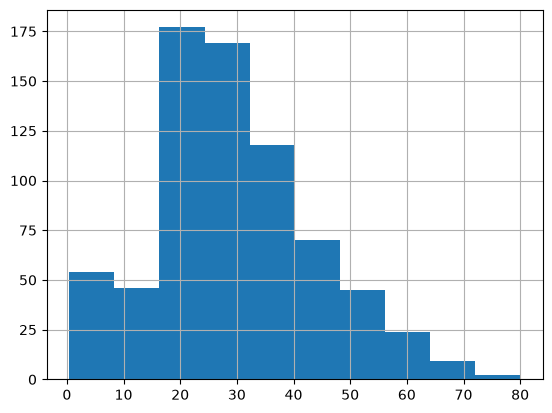

In [34]:
data['Age'].hist()

<Axes: >

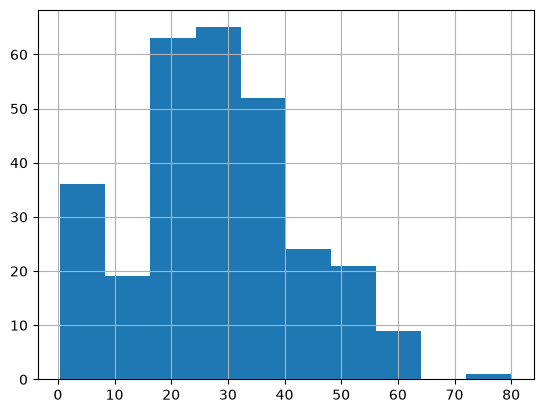

In [36]:
data[data['Survived'] == 1]['Age'].hist()

<Axes: >

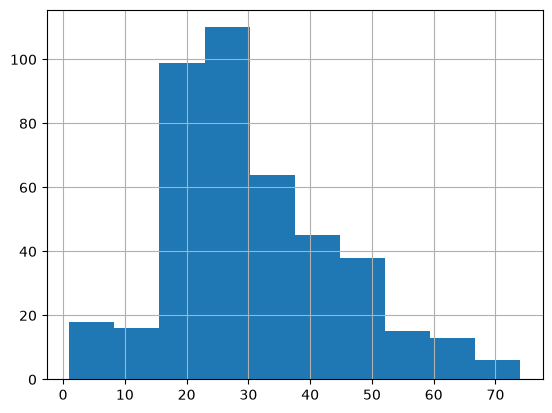

In [37]:
data[data['Survived'] == 0]['Age'].hist()

## Children under 10 years old had a much higher survival rate

In [42]:
data['Child'] = data['Age'] < 10

pd.crosstab(data['Child'], data['Survived'], normalize='index') * 100

Survived,0,1
Child,,
False,63.329312,36.670688
True,38.709677,61.290323


<Axes: >

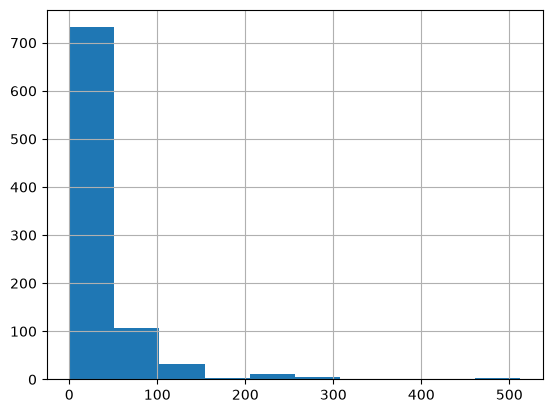

In [43]:
data['Fare'].hist()

In [47]:
print(f"Mediana: {data['Fare'].median()}")
print(f"Mean: {data['Fare'].mean()}")

Mediana: 14.4542
Mean: 32.204207968574636


## If passenger had a 2, 3 or 4 family members then he had more chances to survive

In [49]:
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
pd.crosstab(data['FamilySize'], data['Survived'], normalize='index') * 100

Survived,0,1
FamilySize,,
1,69.646182,30.353818
2,44.720497,55.279503
3,42.156863,57.843137
4,27.586207,72.413793
5,80.000000,20.000000
6,86.363636,13.636364
7,66.666667,33.333333
8,100.000000,0.000000
11,100.000000,0.000000


## Hypothesis
1. Sex is the strongest single predictor of survival(74% of women survived vs 19% of men)
2. Pclass is the second strongest predictor (63% survival in 1st class down to 24% in the 3rd class)
3. Children under 10 had a noticeably higher survival rate than the rest of the passengers
4. Embarked looks correlated with survival, passengers from C were more likely to travel in 1st class
5. Family size has a non-linear relationships with survival: passengers travelling alone or in very large groups survived less often than those in small families (2-4 members)